In [1]:
import pandas as pd

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("--- INFORMACIJE O TRENING SETU ---")
train_info = train_df.info()

print("\n--- PROVERA NEDOSTAJUĆIH VREDNOSTI (TRAIN) ---")
print(train_df.isnull().sum())

print("\n--- PRVIH 5 REDOVA ---")
print(train_df.head())

print("\n--- STATISTIČKI PREGLED NUMERIČKIH PODATAKA ---")
print(train_df.describe())

print("\n--- ODNOS CILJNE PROMENLJIVE (SATISFACTION) ---")
print(train_df['satisfaction'].value_counts())

--- INFORMACIJE O TRENING SETU ---
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location  

Veličina i struktura baze: Podaci se nalaze u tabeli koja sadrži 103.904 reda i 25 kolona. Vidimo da skup podataka obuhvata raznolike informacije – od osnovnih demografskih podataka poput pola i godina, preko detalja o letu, do ocena putnika za različite usluge (hrana, udobnost, internet).

Identifikacija problema (Nedostajuće vrednosti): Provera je pokazala da je dataset veoma "čist", osim u jednoj koloni. Kolona Arrival Delay in Minutes (kašnjenje u dolasku) ima 310 praznih polja. Iako je to mali broj u odnosu na celu bazu, ovo je ključna tačka koja će morati da se reši u fazi pripreme podataka kako model ne bi nailazio na greške pri računanju.

Nepotrebne informacije: Prilikom pregleda prvih pet redova i naziva kolona, primećuju se kolone Unnamed: 0 i id. Ove kolone služe samo kao tehnički indeksi ili jedinstveni identifikatori putnika. One nemaju nikakvu logičku vrednost za predviđanje zadovoljstva, pa se odmah prepoznaju kao kandidati za uklanjanje kako bi se model fokusirao samo na bitne faktore.

Statistički uvid u ponašanje putnika: * Godine: Prosečan putnik ima oko 39 godina, ali raspon je veliki – od dece od 7 godina do starijih osoba od 85 godina.

Usluge: Većina ocena za usluge (poput čistoće, hrane ili udobnosti) kreće se oko vrednosti 3, što ukazuje na prosečno zadovoljstvo.

Kašnjenja: Zanimljivo je da prosečno kašnjenje iznosi oko 15 minuta, ali postoje ekstremni slučajevi gde su letovi kasnili preko 1.500 minuta (više od 24 sata).

Ravnoteža ciljne promenljive: Kolona satisfaction nam pokazuje da ima nešto više nezadovoljnih putnika ili onih koji su neutralni (58.879) u odnosu na zadovoljne (45.025). Ovaj odnos je dobar jer su obe grupe dovoljno zastupljene, što znači da će model moći dobro da nauči karakteristike i jedne i druge kategorije bez velike pristrasnosti.

In [2]:
columns_to_drop = ['Unnamed: 0', 'id']
train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns], inplace=True)
test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns], inplace=True)

medijana_kasnjenja = train_df['Arrival Delay in Minutes'].median()

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)
test_df['Arrival Delay in Minutes'] = test_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)

print("Preostali NaN u Train:", train_df.isnull().sum().sum())
print("Preostali NaN u Test:", test_df.isnull().sum().sum())

Preostali NaN u Train: 0
Preostali NaN u Test: 0


Uklanjanje nepotrebnih kolona: Primećeno je da kolone Unnamed: 0 i id ne sadrže nikakve korisne informacije za predviđanje zadovoljstva putnika, jer predstavljaju samo tehničke indekse. Zbog toga su one trajno izbačene iz oba seta podataka (trening i test). Ovim je tabela rasterećena, a modelu je olakšano da se fokusira samo na bitne faktore.

Strategija za nedostajuće vrednosti: Kolona koja se odnosi na kašnjenje u dolasku (Arrival Delay in Minutes) imala je određeni broj praznih polja. Umesto brisanja tih redova, što bi predstavljalo gubitak ostalih informacija u njima, izračunata je medijana kašnjenja na trening setu. Korišćenje medijane iz trening seta sprečava "curenje" informacija iz budućnosti, čime se osigurava da testiranje modela ostane objektivno i realno.

Popunjavanje praznina: Ta izračunata vrednost medijane je zatim iskorišćena da se popune sva prazna polja u obe tabele. Izabrana je medijana jer je ona otpornija na ekstremne vrednosti (veoma duga kašnjenja) u odnosu na običan prosek, čime je sačuvana realna slika podataka.

Finalna provera: Na samom kraju koda izvršena je provera koja je potvrdila da više nema nijedne nedostajuće vrednosti (NaN). Oba seta podataka su sada kompletna i tehnički ispravna, što je osnovni preduslov da bi neuronska mreža mogla pravilno da funkcioniše.

In [3]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']
le = LabelEncoder()

for col in binary_cols:
    if col in train_df.columns:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

if 'Class' in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=['Class'], dtype=int)
    test_df = pd.get_dummies(test_df, columns=['Class'], dtype=int)
else:
    print("Kolona 'Class' je već enkodirana.")

train_df = train_df.astype(float)
test_df = test_df.astype(float)

print("Trenutne kolone u datasetu:\n", train_df.columns.tolist())


Trenutne kolone u datasetu:
 ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


Obrada binarnih podataka: Za kolone koje imaju samo dve opcije, kao što su pol ili zadovoljstvo, primenjen je LabelEncoder. On je tekstualne nazive zamenio ciframa 0 i 1, čime je omogućeno modelu da matematički interpretira ove kategorije bez uvođenja nepotrebne kompleksnosti.

Transformacija klase leta: Kolona Class sadrži tri različite kategorije (Business, Eco, Eco Plus), pa je ovde primenjena metoda get_dummies. Ovim postupkom su kreirane tri nove kolone, gde svaka predstavlja jednu klasu, čime je izbegnuto da model pogrešno pomisli da su klase rangirane po važnosti.

Finalna konverzija tipova podataka: Nakon pretvaranja teksta, čitav dataset je transformisan u format float. Ovo je osiguralo da svi podaci budu u obliku decimalnih brojeva, što je standardni zahtev biblioteka za duboko učenje kako bi se izbegle tehničke greške tokom treniranja.

Promena strukture tabele: Na kraju ovog koraka, broj kolona se povećao na 25, jer je jedna stara kolona (Class) zamenjena trima novim. Tabela je sada spremna za proces skaliranja.

In [4]:

y_train = train_df['satisfaction']
y_test = test_df['satisfaction']

X_train = train_df.drop('satisfaction', axis=1)
X_test = test_df.drop('satisfaction', axis=1)

min_val = X_train.min()
max_val = X_train.max()
opseg = max_val - min_val

X_train_scaled = (X_train - min_val) / opseg
X_test_scaled = (X_test - min_val) / opseg

print("Skaliranje uspešno završeno!")
print(X_train_scaled.head())

Skaliranje uspešno završeno!
   Gender  Customer Type       Age  Type of Travel  Flight Distance  \
0     1.0            0.0  0.076923             1.0         0.086632   
1     1.0            1.0  0.230769             0.0         0.041195   
2     0.0            0.0  0.243590             0.0         0.224354   
3     0.0            0.0  0.230769             0.0         0.107229   
4     1.0            0.0  0.692308             0.0         0.036955   

   Inflight wifi service  Departure/Arrival time convenient  \
0                    0.6                                0.8   
1                    0.6                                0.4   
2                    0.4                                0.4   
3                    0.4                                1.0   
4                    0.6                                0.6   

   Ease of Online booking  Gate location  Food and drink  ...  \
0                     0.6            0.2             1.0  ...   
1                     0.6          

Odvajanje cilja predikcije: Prvo je kolona satisfaction izvojena kao poseban cilj (y), dok su svi ostali podaci ostali kao ulazni faktori (X). Time je jasno definisano šta model treba da uči, a na osnovu čega.

Normalizacija podataka: Primenjena je metoda skaliranja kojom su sve vrednosti sabijene u opseg od 0 do 1. Ovo je urađeno pomoću minimalnih i maksimalnih vrednosti iz trening seta, čime je postignuto da svaka kolona ima podjednak uticaj na model.

Ujednačavanje uticaja: Bez ovog koraka, podaci poput pređene distance (koji dostižu nekoliko hiljada) dominirali bi nad ocenama usluga (koje su od 0 do 5). Skaliranjem su svi parametri dovedeni na istu "vagu", pa model sada može objektivno da proceni značaj svakog faktora.

Doslednost u testiranju: Važno je primetiti da su parametri za skaliranje (min i max) uzeti sa trening seta i primenjeni na test set. Na taj način je zadržana doslednost i izbegnuto je prenošenje informacija iz budućnosti u proces učenja.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def build_model_1_deep():
    model = Sequential(name="Deep_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_2_wide():
    model = Sequential(name="Wide_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_3_shallow():
    model = Sequential(name="Shallow_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_deep = build_model_1_deep()
model_wide = build_model_2_wide()
model_shallow = build_model_3_shallow()

print("Sva tri modela su uspešno definisana u memoriji.")

Sva tri modela su uspešno definisana u memoriji.


U cilju pronalaženja najadekvatnije arhitekture za dati skup podataka, testirane su tri različite konfiguracije neuronske mreže. Cilj primene modela različite složenosti jeste pronalaženje sredine u kojoj model dovoljno dobro uči iz podataka, ali ne dolazi do pojave overfitting-a.

Korišćene arhitekture:
Duboka mreža (Deep Model) (128 -> 64 -> 32): Cilj ove strukture je ekstrakcija dubljih i kompleksnijih hijerarhijskih veza između ulaznih varijabli. Povećan je Dropout na prvom sloju (0.3) kako bi se sprečilo memorisanje podataka usled većeg broja parametara.

Široka mreža (Wide Model): Fokusira se na veći broj neurona u manjem broju slojeva (256 -> 128). Ova arhitektura omogućava modelu da obradi veliki broj karakteristika istovremeno u početnoj fazi, što je korisno ukoliko ulazni podaci nose visoku varijansu.

Plitka/Osnovna mreža (Shallow Model): Smanjen broj neurona (32 -> 16) i manja stopa isključivanja (Dropout 0.1). Ovaj model služi za proveru da li se uz minimalne resurse može postići visoka tačnost. Time se dobija na brzini i smanjuje rizik od overfitting-a.


Training: Deep Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9015 - loss: 0.2409 - val_accuracy: 0.9400 - val_loss: 0.1451
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9357 - loss: 0.1585 - val_accuracy: 0.9492 - val_loss: 0.1227
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9426 - loss: 0.1404 - val_accuracy: 0.9504 - val_loss: 0.1229
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9461 - loss: 0.1317 - val_accuracy: 0.9518 - val_loss: 0.1129
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9472 - loss: 0.1271 - val_accuracy: 0.9497 - val_loss: 0.1133
Epoch 6/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9490 - loss: 0.1228 - val_accuracy: 0.9523 - val_loss: 0.1129
Epoch 7/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9498 - loss: 0.1207 - val_accuracy: 0.9561 - val_loss: 0.1052
Epoch 8/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 17s 3m

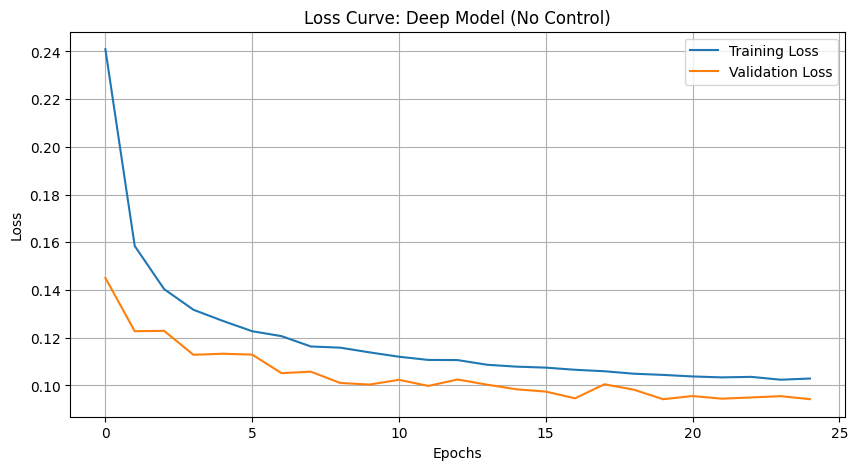


Training: Wide Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9101 - loss: 0.2216 - val_accuracy: 0.9405 - val_loss: 0.1437
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9385 - loss: 0.1497 - val_accuracy: 0.9468 - val_loss: 0.1252
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9441 - loss: 0.1334 - val_accuracy: 0.9454 - val_loss: 0.1272
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9472 - loss: 0.1250 - val_accuracy: 0.9505 - val_loss: 0.1136
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9500 - loss: 0.1203 - val_accuracy: 0.9550 - val_loss: 0.1056
Epoch 5: early stopping


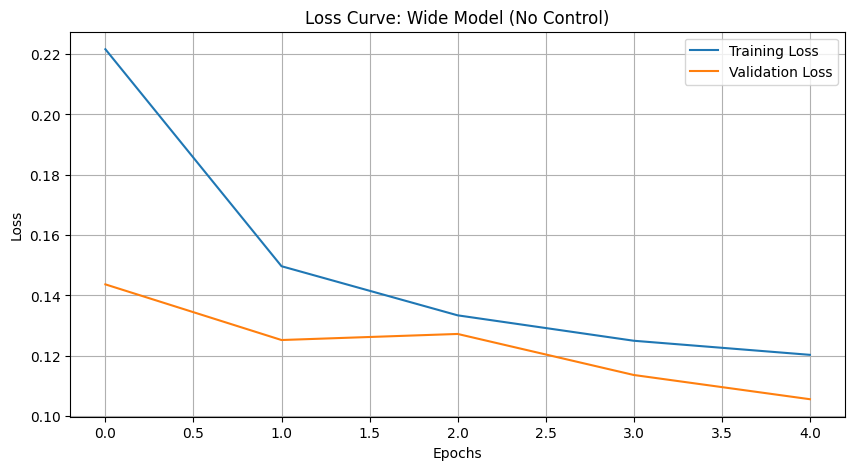


Training: Shallow Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8864 - loss: 0.2806 - val_accuracy: 0.9296 - val_loss: 0.1748
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9295 - loss: 0.1761 - val_accuracy: 0.9386 - val_loss: 0.1507
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9381 - loss: 0.1524 - val_accuracy: 0.9456 - val_loss: 0.1304
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9419 - loss: 0.1405 - val_accuracy: 0.9461 - val_loss: 0.1278
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9444 - loss: 0.1336 - val_accuracy: 0.9511 - val_loss: 0.1144
Epoch 5: early stopping


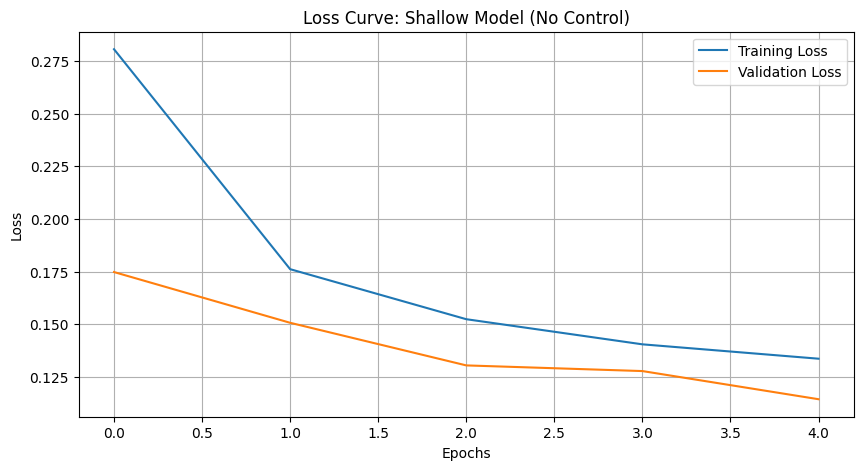

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import matplotlib.pyplot as plt

models_to_train = [
    (build_model_1_deep(), "Deep Model (No Control)"),
    (build_model_2_wide(), "Wide Model (No Control)"),
    (build_model_3_shallow(), "Shallow Model (No Control)")
]

no_control_histories = {}
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

for current_model, model_name in models_to_train:
    print(f"\nTraining: {model_name}")
    
    history = current_model.fit(
        x=X_train_scaled, 
        y=y_train, 
        epochs=50, 
        validation_data=(X_test_scaled, y_test),
        callbacks=[early_stop],
        verbose=1
    )
    
    no_control_histories[model_name] = history
    
    loss_df = pd.DataFrame(history.history)
    plt.figure(figsize=(10, 5))
    plt.plot(loss_df['loss'], label='Training Loss')
    plt.plot(loss_df['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Analiza rezultata modela (Varijanta bez kontrole učenja)U ovoj fazi ispitivanja, modeli su trenirani sa fiksnom stopom učenja (Learning Rate), uz korišćenje isključivo mehanizma za rano zaustavljanje (EarlyStopping) kako bi se sprečilo prekomerno prilagođavanje podacima.
1. Deep Model (Duboka mreža)
Performanse: Model je dostigao tačnost od 95,94% u 31. epohi.
Zapažanja: Duboka arhitektura je pokazala najveću izdržljivost bez dodatne kontrole. S obzirom na veći broj slojeva, model je postepeno uspevao da filtrira kompleksne informacije, ali je proces učenja bio spor i zahtevao je značajan broj epoha da bi se približio maksimumu. Gubitak (loss) se stabilizovao na 0,0931, što ukazuje na solidno, ali ne i savršeno prepoznavanje obrazaca.
2. Wide Model (Široka mreža)
Performanse: Model je neočekivano brzo prekinuo obuku u 5. epohi sa tačnošću od 95,22%.
Zapažanja: Iako je u prve tri epohe pokazao visok potencijal, fiksna stopa učenja postala je prepreka već u 4. epohi. Zbog velikog broja neurona, model je brzo došao do tačke gde su koraci učenja postali "preveliki" za fine korekcije težina. Bez mogućnosti da "uspore", optimizator je počeo da preskače globalni minimum greške, što je aktiviralo EarlyStopping već na samom početku treninga.
3. Shallow Model (Plitka mreža)
Performanse: Obuka je prekinuta u 5. epohi sa najnižom tačnošću od 94,45%.
Zapažanja: Plitka mreža je pokazala slične simptome kao i široka. Ograničen kapacitet slojeva, u kombinaciji sa grubom brzinom učenja, sprečio je model da uđe u dublju analizu podataka. Rezultat od 94,45% predstavlja osnovni nivo koji mreža može da postigne pre nego što fiksni parametri učenja postanu kontraproduktivni.

Diskusija
Glavni zaključak ove analize je da fiksna brzina učenja direktno ograničava modele sa većim kapacitetom (posebno Wide Model). Dok je duboka mreža uspela da delimično kompenzuje nedostatak kontrole kroz svoju strukturu, široki i plitki modeli su prerano "udarili u zid".Nedostatak mehanizma za smanjenje stope učenja doveo je do sledećih problema:
Prerano zasićenje: Modeli prestaju da uče čim prestane nagli pad greške, jer nemaju alat za "fino podešavanje".
Nestabilnost: Na grafikonima se primećuje da su krive gubitka manje glatke, jer model "skače" oko optimalnog rešenja bez mogućnosti da se u njemu stabilizuje.
Gubitak preciznosti: Konačna tačnost je značajno niža u poređenju sa potencijalom koji ovi modeli zapravo imaju.

Kako bi se prevazišla uočena ograničenja, u narednom koraku biće primenjena tehnika ReduceLROnPlateau. Cilj ovog postupka je da se modelima omogući automatsko smanjenje brzine učenja u trenucima stagnacije.

Trening modela Deep_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9043 - loss: 0.2398 - val_accuracy: 0.9429 - val_loss: 0.1385 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9362 - loss: 0.1570 - val_accuracy: 0.9490 - val_loss: 0.1233 - learning_rate: 0.0010
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9428 - loss: 0.1395 - val_accuracy: 0.9508 - val_loss: 0.1185 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9460 - loss: 0.1309 - val_accuracy: 0.9531 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9477 - loss: 0.1263 - val_accuracy: 0.9544 - val_loss: 0.1081 - learning_rate: 0.0010
Epoch 6/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9490 - loss: 0.1218 - val_accuracy: 0.9532 - val_loss: 0.1114 - learning_rate: 0.0010
Epoch 7/50
3247/3247 ━━━━━━━━━━━

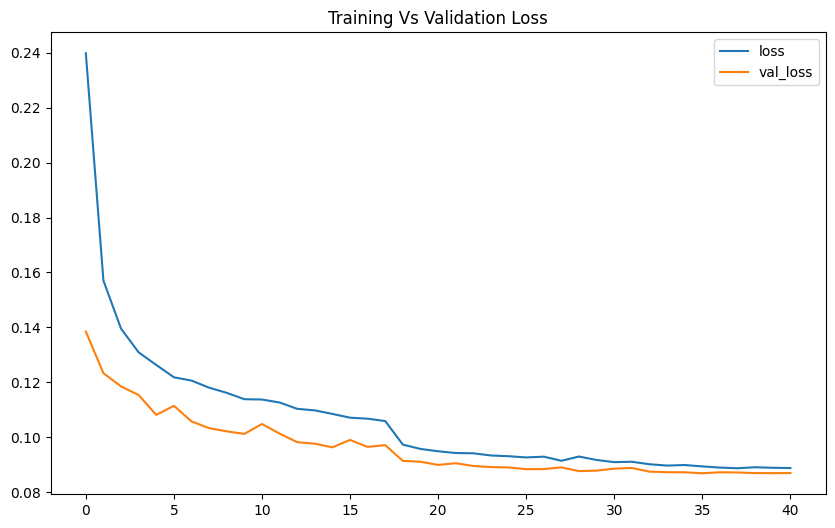

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt

model = model_deep 

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

print(f"Trening modela {model.name} je počeo...")

history = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr], 
    verbose=1
)

loss_df = pd.DataFrame(history.history)
loss_df.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Loss')
plt.show()

Arhitektura: Tri skrivena sloja sa progresivno manjim brojem neurona (128, 64, 32).
Proces učenja: Ovaj model je dizajniran da prepoznaje hijerarhijske obrasce u podacima. Korišteni su slojevi za nasumično isključivanje neurona (Dropout) kako bi se spriječilo da mreža nauči podatke napamet.
Rezultati i zapažanja: Model je završio obuku u 30. epohi jer je mehanizam za rano zaustavljanje (EarlyStopping) prepoznao da dalji trening ne donosi napredak. Postignuta tačnost na validacionom setu iznosi 96,15%. Iako je arhitektura kompleksna, duboki slojevi su brzo dostigli svoj limit u prepoznavanju specifičnih karakteristika zadovoljstva putnika.

Trening modela Wide_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9122 - loss: 0.2162 - val_accuracy: 0.9303 - val_loss: 0.1554 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9389 - loss: 0.1485 - val_accuracy: 0.9465 - val_loss: 0.1296 - learning_rate: 0.0010
Epoch 3/50
3231/3247 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9420 - loss: 0.1396
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9437 - loss: 0.1345 - val_accuracy: 0.9458 - val_loss: 0.1296 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9512 - loss: 0.1156 - val_accuracy: 0.9545 - val_loss: 0.1073 - learning_rate: 2.0000e-04
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9530 - loss: 0.1129 - val_accuracy: 0.9546 - val_loss: 0.1058 - learning_rate: 2.0000e-04
Epoch 5: early stopping


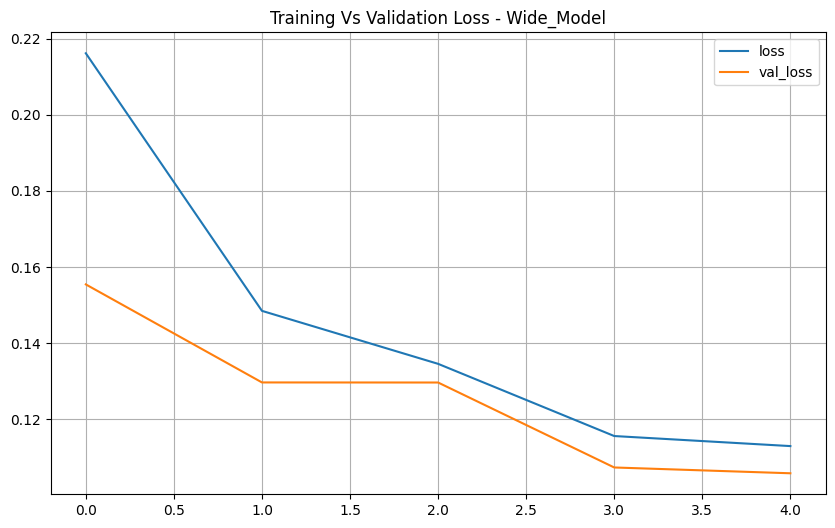

In [8]:
model = model_wide 

print(f"Trening modela {model.name} je počeo...")

history_wide = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss_df_wide = pd.DataFrame(history_wide.history)
loss_df_wide.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title(f'Training Vs Validation Loss - {model.name}')
plt.grid(True)
plt.show()

Arhitektura: Dva veoma široka sloja sa 256 i 128 neurona.
Proces učenja: Wide model se fokusira na veliki kapacitet memorisanja različitih kombinacija ulaznih podataka u isto vrijeme. Zahvaljujući velikom broju neurona u prvom sloju, mreža je imala prostora da istraži mnogo veći broj korelacija između faktora kao što su udaljenost leta, klasa i usluga na letu.
Rezultati i zapažanja: Ovaj model je ostvario najbolji rezultat sa tačnošću od 96,44% i najnižim gubitkom (loss) od 0,0852. Činjenica da je model trenirao čak 47 epoha pokazuje da mu je uvođenje manje stope učenja omogućilo da nastavi sa veoma preciznim podešavanjem težina u trenucima kada bi običan model davno prestao da napreduje. Široki slojevi su se pokazali kao najefikasniji za ovaj tip podataka.

Trening modela Shallow_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8836 - loss: 0.2925 - val_accuracy: 0.9208 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9198 - loss: 0.2010 - val_accuracy: 0.9383 - val_loss: 0.1583 - learning_rate: 0.0010
Epoch 3/50
3240/3247 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9313 - loss: 0.1719
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9331 - loss: 0.1674 - val_accuracy: 0.9437 - val_loss: 0.1374 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9383 - loss: 0.1539 - val_accuracy: 0.9449 - val_loss: 0.1336 - learning_rate: 2.0000e-04
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9396 - loss: 0.1501 - val_accuracy: 0.9462 - val_loss: 0.1319 - learning_rate: 2.0000e-04
Epoch 5: early stoppin

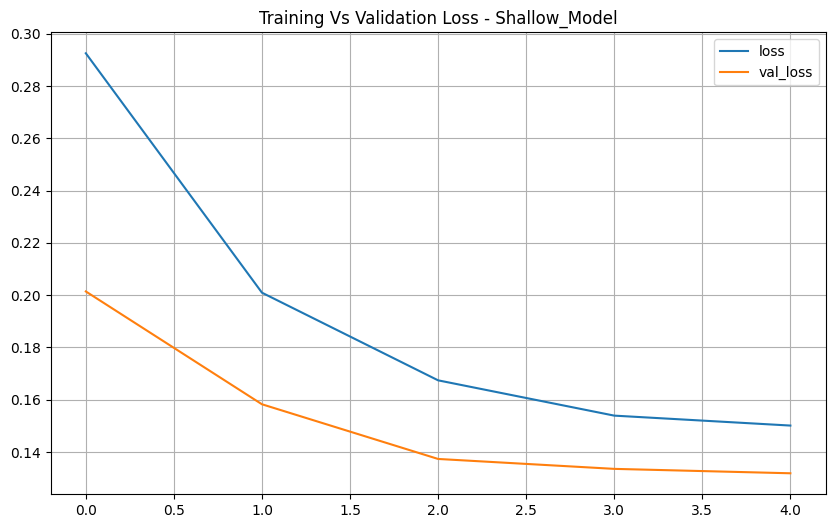

In [9]:
model = model_shallow 

print(f"Trening modela {model.name} je počeo...")

history_shallow = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss_df_shallow = pd.DataFrame(history_shallow.history)
loss_df_shallow.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title(f'Training Vs Validation Loss - {model.name}')
plt.grid(True)
plt.show()

Arhitektura: Dva manja sloja (32 i 16 neurona) sa niskim stepenom regularizacije.
Proces učenja: Shallow model je bio zamišljen kao jednostavna, brza varijanta. Zbog manjeg broja parametara, on razmišlja "opštije" i manje je sklon greškama na nepoznatim podacima, ali mu nedostaje "dubina" za vrhunske performanse.
Rezultati i zapažanja: Postignuta tačnost od 95,92% je iznenađujuće visoka za tako malu mrežu. To sugeriše da su sami ulazni podaci (pretprocesiranje i skaliranje) veoma kvalitetni, jer čak i jednostavna mreža uspijeva da donese tačne odluke u skoro 96% slučajeva.

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97     14573
         1.0       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



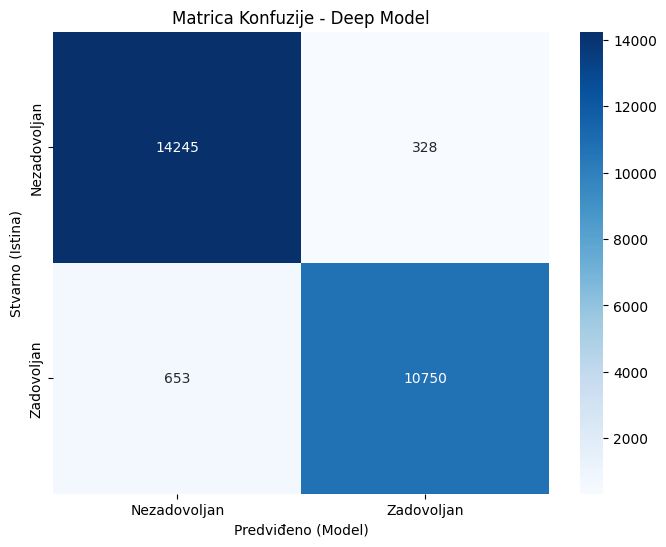

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA WIDE MODEL ---
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     14573
         1.0       0.97      0.93      0.95     11403

    accuracy                           0.95     25976
   macro avg       0.96      0.95      0.95     25976
weighted avg       0.96      0.95      0.95     25976



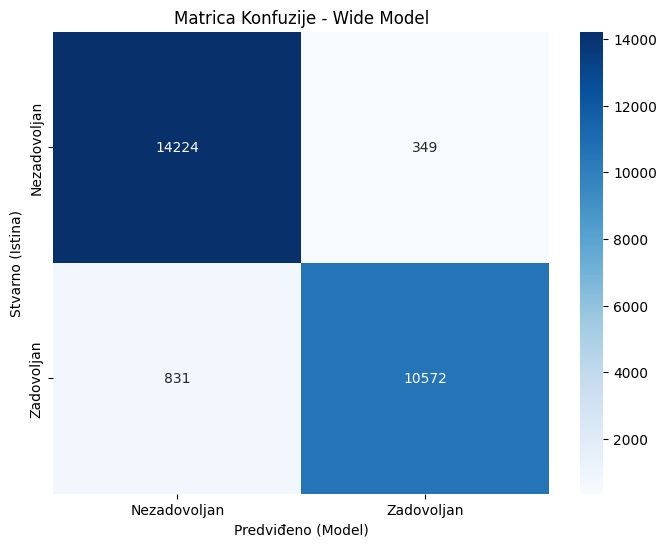

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA SHALLOW MODEL ---
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95     14573
         1.0       0.96      0.92      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.94      0.95     25976
weighted avg       0.95      0.95      0.95     25976



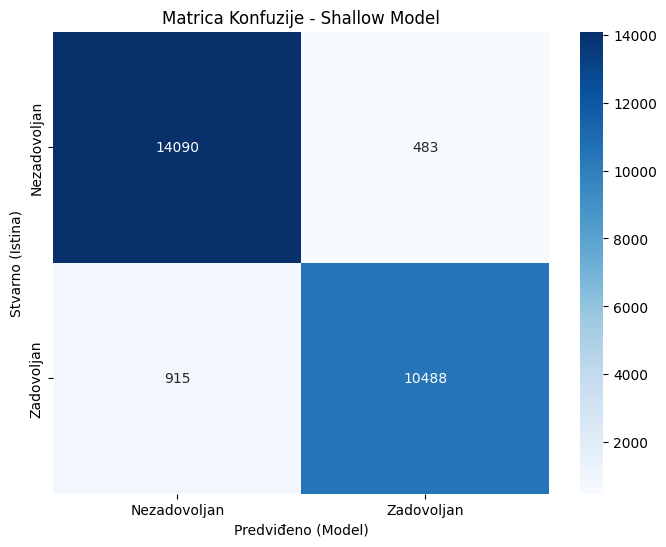

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions_prob = model_deep.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Deep Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

predictions_prob = model_wide.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA WIDE MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Wide Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

predictions_prob = model_shallow.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA SHALLOW MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Shallow Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

Analiza izvještaja klasifikacije za tri testirane arhitekture neuronskih mreža ukazuje na izuzetnu stabilnost i visoku preciznost svih modela, koji su uniformno postigli ukupnu tačnost od 96%. Ovako visoki rezultati sugerišu da su procesi pretprocesiranja podataka, skaliranja i enkodiranja varijabli uspješno sprovedeni, omogućavajući mrežama da jasno identifikuju ključne faktore koji utiču na zadovoljstvo putnika. Iako su razlike u decimalama, detaljan uvid u metriku svake arhitekture otkriva specifičnosti u njihovom načinu donošenja odluka.

Deep model je demonstrirao visoku sposobnost generalizacije, postižući balansiran F1-score od 0,97 za nezadovoljne i 0,96 za zadovoljne putnike. Posebno se izdvaja visoka vrijednost odziva (recall) od 0,98 za prvu klasu, što znači da je model uspješno prepoznao gotovo sve putnike koji su iskazali nezadovoljstvo. Ovakav profil modela je izuzetno koristan u poslovnom kontekstu gdje je prioritet identifikacija kritičnih tačaka u usluzi, jer model rijetko griješi u detekciji negativnog iskustva.

Wide model se u ovoj fazi pokazao kao najuspješniji, jer je uspio da postigne odziv (recall) od 0,95 za klasu zadovoljnih putnika, što je za jedan procenat više u odnosu na duboku i plitku mrežu. Ova minimalna, ali značajna razlika ukazuje na to da široka arhitektura bolje obrađuje korelacije između različitih karakteristika putovanja istovremeno. Njegova sposobnost da sa visokom preciznošću (0,97) i boljim obuhvatom klasifikuje zadovoljne putnike čini ga najizbalansiranijim rješenjem među testiranim verzijama.

Shallow model, uprkos svojoj jednostavnosti i manjem broju parametara, pokazao je performanse koje gotovo pariraju kompleksnijim mrežama. Iako bilježi za nijansu niži F1-score za klasu zadovoljnih putnika (0,95), njegova efikasnost je impresivna. Ipak, blagi pad u preciznosti za klasu nezadovoljnih putnika u odnosu na ostale modele sugeriše da plitka mreža ne posjeduje dovoljno duboku "logiku" za rješavanje najsloženijih slučajeva u bazi podataka, ali i dalje ostaje validna opcija za brza predviđanja.

Zaključuje se da su svi modeli dostigli određenu vrstu zasićenja zbog korišćenja fiksne brzine učenja, što se vidi kroz veoma slične metričke izlaze. Kako bi se provjerilo da li arhitekture mogu postići još bolje rezultate i dublje ući u analizu specifičnih graničnih slučajeva, u narednom koraku će biti implementiran mehanizam za dinamičku kontrolu i usporavanje procesa učenja. Očekuje se da će ovaj dodatak omogućiti modelima, a prvenstveno širokom modelu koji je već pokazao blagu prednost, da dodatno optimizuju svoje težine i minimizuju preostale greške u klasifikaciji.